# 深度学习入门-卷积神经网络（CNN）
本文围绕从零开始实现一个卷积神经网络（CNN）来进行手写数字识别的任务。

## 1. 数据集准备
这里使用 Mnist 数据集，它包含了 60000 张训练图片和 10000 张测试图片，每张图片都是 28x28 像素的灰度图像。使用现成的 `load_mnist` 代码加载数据集。

In [17]:
import os
import urllib.request
import os.path
import gzip
import pickle
import os
import numpy as np

url_base = 'https://ossci-datasets.s3.amazonaws.com/mnist/'  # mirror site
key_file = {
    'train_img':'train-images-idx3-ubyte.gz',
    'train_label':'train-labels-idx1-ubyte.gz',
    'test_img':'t10k-images-idx3-ubyte.gz',
    'test_label':'t10k-labels-idx1-ubyte.gz'
}

dataset_dir = f"./dataset"
save_file = dataset_dir + "/mnist.pkl"

train_num = 60000
test_num = 10000
img_dim = (1, 28, 28)
img_size = 784


def _download(file_name):
    file_path = dataset_dir + "/" + file_name
    
    if os.path.exists(file_path):
        return

    print("Downloading " + file_name + " ... ")
    urllib.request.urlretrieve(url_base + file_name, file_path)
    print("Done")
    
def download_mnist():
    for v in key_file.values():
       _download(v)
        
def _load_label(file_name):
    file_path = dataset_dir + "/" + file_name
    
    print("Converting " + file_name + " to NumPy Array ...")
    with gzip.open(file_path, 'rb') as f:
            labels = np.frombuffer(f.read(), np.uint8, offset=8)
    print("Done")
    
    return labels

def _load_img(file_name):
    file_path = dataset_dir + "/" + file_name
    
    print("Converting " + file_name + " to NumPy Array ...")    
    with gzip.open(file_path, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
    data = data.reshape(-1, img_size)
    print("Done")
    
    return data
    
def _convert_numpy():
    dataset = {}
    dataset['train_img'] =  _load_img(key_file['train_img'])
    dataset['train_label'] = _load_label(key_file['train_label'])    
    dataset['test_img'] = _load_img(key_file['test_img'])
    dataset['test_label'] = _load_label(key_file['test_label'])
    
    return dataset

def init_mnist():
    download_mnist()
    dataset = _convert_numpy()
    print("Creating pickle file ...")
    with open(save_file, 'wb') as f:
        pickle.dump(dataset, f, -1)
    print("Done!")

def _change_one_hot_label(X):
    T = np.zeros((X.size, 10))
    for idx, row in enumerate(T):
        row[X[idx]] = 1
        
    return T
    

def load_mnist(normalize=True, flatten=True, one_hot_label=False):
    """读入MNIST数据集
    
    Parameters
    ----------
    normalize : 将图像的像素值正规化为0.0~1.0
    one_hot_label : 
        one_hot_label为True的情况下，标签作为one-hot数组返回
        one-hot数组是指[0,0,1,0,0,0,0,0,0,0]这样的数组
    flatten : 是否将图像展开为一维数组
    
    Returns
    -------
    (训练图像, 训练标签), (测试图像, 测试标签)
    """
    if not os.path.exists(save_file):
        init_mnist()
        
    with open(save_file, 'rb') as f:
        dataset = pickle.load(f)
    
    if normalize:
        for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].astype(np.float32)
            dataset[key] /= 255.0
            
    if one_hot_label:
        dataset['train_label'] = _change_one_hot_label(dataset['train_label'])
        dataset['test_label'] = _change_one_hot_label(dataset['test_label'])
    
    if not flatten:
         for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].reshape(-1, 1, 28, 28)

    return (dataset['train_img'], dataset['train_label']), (dataset['test_img'], dataset['test_label']) 


## 2. 神经网络层的实现
在本节中，我们将实现卷积层、池化层和全连接层。每个层都将包含前向传播和反向传播的实现。

### 2.1 卷积层
在全连接层（Affine层）中，需要将输入数据拉平为1维数据。图像是3维形状，应该含有重要的空间信息，因为全连接层会忽略形状，将全部的输入数据作为相同的神经元处理，所以无法利用形状相关的信息。而卷积层可以保持形状不变，当输入数据是图像时，卷积层会以3维数据的形式接收输入数据，并同样以3维数据的形式输出至下一层。

#### 2.1.1 卷积运算

卷积运算相当于图像处理的“滤波器运算”。

![图1：卷积运算的例子](./assets/1-Convolution.svg)

如图1所示，卷积运算对输入数据应用滤波器。在这个例子中，输入大小是(4, 4)，滤波器大小是(3, 3)，步长为1，填充为0。输出大小为(2, )。如图2所示，在这个过程中，滤波器在输入数据上滑动，将对应位置元素相乘，然后再求和（有时将这个计算称为乘积累加运算），生成输出数据。

![图2：卷积运算的计算过程](./assets/2-Convolution.svg)

CNN中，滤波器的参数就对应之前的权重，并且，CNN中也存在偏置。包含偏执的卷积运算的处理流如图3所示。

![图3：包含偏置的卷积运算](./assets/3-Convolution.svg)

偏执通常只有1个值，应用于每个输出数据。

#### 2.1.2 填充
填充（Padding）是指在输入数据的边缘添加额外的像素，以控制输出数据的大小。填充可以防止卷积操作导致输出数据尺寸过小。

![图4：填充的例子](./assets/4-Padding.svg)

如图4所示，通过填充，大小为(4, 4)的输入数据变成了(6, 6)，滤波器大小为(3, 3)，步长为1，填充为1。输出大小变成了(4, 4)。

#### 2.1.3 步长
步长（Stride）是指滤波器在输入数据上滑动的步幅。步长可以控制输出数据的大小。

![图5：步长的例子](./assets/5-Stride.svg)

如图5所示，步长为2时，输入数据大小为(4, 4)，滤波器大小为(3, 3)，填充为0，输出大小变成了(2, 2)。

综上，可以用填充和步幅控制输出的大小，假设输入大小为(H, W)，滤波器大小为(FH, FW)，输出大小为(OH, OW)，填充为P，步长为S，则输出大小为：
$$
\begin{aligned}
OH &= \frac{H + 2P - FH}{S} + 1  \\
OW &= \frac{W + 2P - FW}{S} + 1
\end{aligned}
$$

注意，如果输出大小不是整数，则需要采取报错等对策。根据框架的不同，有时会使用向下取整的方式来处理。

#### 2.1.4 3维数据的卷积
之前的卷积运算的例子都是以高、长两个方向的2维形状为对象，但是，图象是三维数据，除了高、长两个方向外，还需要处理通道方向。图6是3维卷积运算的例子，他在纵深方向上有三个通道，对应的滤波器也增加到了三个。运算时，按通道进行输入数据和滤波器的卷积运算，并将结果相加，从而得到2维的输出。

![图6：3维数据的卷积运算](./assets/6-3D_Convolution.svg)

需要注意的是，滤波器的通道数只能设定为和输入数据的通道数相同的值。

#### 2.1.5 结合方块思考
将数据和滤波器结合长方体的方块来考虑，可以更好地理解卷积运算。图7展示了一个3维数据的卷积运算，其中输入数据和滤波器都被视为方块。

![图7：结合方块思考的卷积运算](./assets/7-3D_Convolution_Block.svg)

在这个例子中，数据输出是1张特征图，也就是通道数为1的特征图，如果要在通道方向上增加特征图的数量，可以使用多个滤波器进行卷积运算。图8展示了一个3维数据的卷积运算，其中输入数据和滤波器都被视为方块，输出了多个特征图，并且追加了偏置项。

![图8：多个特征图的卷积运算（追加了偏置项）](./assets/8-3D_Convolution_Multiple_Channels.svg)

之前的处理还只是处理一张图片，如果进行将输入数据打包的批处理，则需要将各层间传递的数据保存为4维数据，具体就是按照 (batch_num, channel, height, weight) 的顺序存放数据。图9展示了一个批处理的卷积运算，其中输入数据和滤波器都被视为方块，输出了多个特征图。批处理将N次数据汇总为1次进行。

![图9：批处理的卷积运算](./assets/9-3D_Convolution_Batch.svg)

#### 2.1.6 卷积层的实现
前面讲到CNN中各层传递的数据是一个4维数据，为了更高效的处理数据，会用到 `im2col` 和 `col2im` 函数。`im2col` 函数将输入数据转换为列向量的形式，`col2im` 函数则将列向量转换回原来的形状。

假设有一个输入是 (1, 3, 9, 9)，滤波器是 (1, 3, 3, 3)，步长为3，填充为0。通过计算得出 out_h=3，out_w=3。其输入转换成col数组的运算过程如图10所示。

![图10：im2col的计算过程](./assets/10-im2col_processing.svg)

右侧是一个新的五维数组，将它在九宫格中对应编号位置的元素组合在一起，就是原来四维数组的一个卷积运算单元，使用`col = col.transpose(0, 4, 5, 1, 2, 3).reshape(N*out_h*out_w, -1)`将其展开成二维数组。

![图11：col数组展平成二维数组](./assets/11-col2D.svg)

图11中，二维数组的一行就是对应于的一个卷积运算单元。同理，`col2im`的过程就是`im2col`的逆过程，这里不再解释，python代码如下：

In [18]:
def im2col(input_data, filter_h, filter_w, stride=1, pad=0):
    """

    Parameters
    ----------
    input_data : 由(数据量, 通道, 高, 长)的4维数组构成的输入数据
    filter_h : 滤波器的高
    filter_w : 滤波器的长
    stride : 步幅
    pad : 填充

    Returns
    -------
    col : 2维数组
    """
    N, C, H, W = input_data.shape
    out_h = (H + 2*pad - filter_h)//stride + 1
    out_w = (W + 2*pad - filter_w)//stride + 1

    img = np.pad(input_data, [(0,0), (0,0), (pad, pad), (pad, pad)], 'constant')
    col = np.zeros((N, C, filter_h, filter_w, out_h, out_w))

    for y in range(filter_h):
        y_max = y + stride*out_h
        for x in range(filter_w):
            x_max = x + stride*out_w
            col[:, :, y, x, :, :] = img[:, :, y:y_max:stride, x:x_max:stride]

    col = col.transpose(0, 4, 5, 1, 2, 3).reshape(N*out_h*out_w, -1)
    return col


def col2im(col, input_shape, filter_h, filter_w, stride=1, pad=0):
    """

    Parameters
    ----------
    col :
    input_shape : 输入数据的形状（例：(10, 1, 28, 28)）
    filter_h :
    filter_w
    stride
    pad

    Returns
    -------

    """
    N, C, H, W = input_shape
    out_h = (H + 2*pad - filter_h)//stride + 1
    out_w = (W + 2*pad - filter_w)//stride + 1
    col = col.reshape(N, out_h, out_w, C, filter_h, filter_w).transpose(0, 3, 4, 5, 1, 2)

    img = np.zeros((N, C, H + 2*pad + stride - 1, W + 2*pad + stride - 1))
    for y in range(filter_h):
        y_max = y + stride*out_h
        for x in range(filter_w):
            x_max = x + stride*out_w
            img[:, :, y:y_max:stride, x:x_max:stride] += col[:, :, y, x, :, :]

    return img[:, :, pad:H + pad, pad:W + pad]

![图12：卷积运算的im2col处理](./assets/12-im2col.svg)

In [19]:
import numpy as np

class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad

        # 中间数据（backward时使用）
        self.x = None   
        self.col = None
        self.col_W = None
        
        # 权重和偏置参数的梯度
        self.dW = None
        self.db = None

    def forward(self, x):
        FN, C, FH, FW = self.W.shape
        N, C, H, W = x.shape
        out_h = int((H + 2 * self.pad - FH) / self.stride + 1)
        out_w = int((W + 2 * self.pad - FW) / self.stride + 1)

        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T
        out = np.dot(col, col_W) + self.b

        out = out.reshape(N, out_h, out_w, -1).transpose(0, 3, 1, 2)

        self.x = x
        self.col = col
        self.col_W = col_W

        return out
    
    def backward(self, dout):
        FN, C, FH, FW = self.W.shape
        dout = dout.transpose(0,2,3,1).reshape(-1, FN)

        self.db = np.sum(dout, axis=0)
        self.dW = np.dot(self.col.T, dout)
        self.dW = self.dW.transpose(1, 0).reshape(FN, C, FH, FW)

        dcol = np.dot(dout, self.col_W.T)
        dx = col2im(dcol, self.x.shape, FH, FW, self.stride, self.pad)

        return dx

为了更好地理解反向传播的过程，先构建一个简单的卷积计算模型。

![图13：卷积层前向传播](./assets/13-Convolution_forward.svg)

将图1表达成数学表达

$$
\begin{rcases}
\begin{aligned}
y_1 &= w_1x_{11} + w_2x_{12} + w_3x_{21} + w_4x_{22} + b \\
y_2 &= w_1x_{12} + w_2x_{13} + w_3x_{22} + w_4x_{23} + b \\
y_2 &= w_1x_{21} + w_2x_{22} + w_3x_{31} + w_4x_{32} + b \\
y_2 &= w_1x_{22} + w_2x_{23} + w_3x_{32} + w_4x_{33} + b
\end{aligned}
\end{rcases} \underset{\text{softmax}}{\Rightarrow} L
$$

则 $\frac{\partial L}{\partial W}$ 可表示为

$$
\begin{cases}
\begin{aligned}
\frac{\partial L}{\partial w_1} &= \frac{\partial L}{\partial y_1}x_{11} + \frac{\partial L}{\partial y_2}x_{12} + \frac{\partial L}{\partial y_3}x_{21} + \frac{\partial L}{\partial y_4}x_{22} \\
\frac{\partial L}{\partial w_2} &= \frac{\partial L}{\partial y_1}x_{12} + \frac{\partial L}{\partial y_2}x_{13} + \frac{\partial L}{\partial y_3}x_{22} + \frac{\partial L}{\partial y_4}x_{23} \\
\frac{\partial L}{\partial w_3} &= \frac{\partial L}{\partial y_1}x_{21} + \frac{\partial L}{\partial y_2}x_{22} + \frac{\partial L}{\partial y_3}x_{31} + \frac{\partial L}{\partial y_4}x_{32} \\
\frac{\partial L}{\partial w_4} &= \frac{\partial L}{\partial y_1}x_{22} + \frac{\partial L}{\partial y_2}x_{23} + \frac{\partial L}{\partial y_3}x_{32} + \frac{\partial L}{\partial y_4}x_{33}
\end{aligned}
\end{cases}
$$

矩阵计算过程可表示为图2

![图14：权重梯度的矩阵计算](./assets/14-Weight_gradient.svg)

$\frac{\partial L}{\partial b}$ 的梯度与全连接层中的偏置梯度计算方法相同，都是0轴方向上的元素之和，不再作出解释。

### 2.2 Relu 层
Rele 层是一个常用的激活函数层，它将输入中的负值置为零，正值保持不变。假设输入的 `x` 是一个numpy数组，Rele 层的前向传播和反向传播可以实现如下：

In [20]:
class Relu:
    def __init__(self):
        self.mask = None
    
    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out
    
    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

由计算图推导可知，如果正向传播时的输入值小于等于0，则反向传播的值为零，否则为正向传播的输入值。

### 2.3 池化层
#### 2.3.1 池化运算
池化是缩小高、长方向上的空间的运算。如图11所示，池化层通过对输入数据进行下采样来减少数据的维度。

![图15：MAX池化层的例子](./assets/15-Pooling.svg)

在池化层中，通常会使用最大池化（Max Pooling）或平均池化（Average Pooling）。最大池化是取池化区域内的最大值，而平均池化是取池化区域内的平均值。另外，一般来说，池化层的步长和池化区域的大小相同。

**池化层的特征**
池化层具有以下特征：
1. **没有要学习的参数**：池化层和卷积层不同，池化层没有要学习的参数，他只是从目标区域中取最大值（或者平均值）。
2. **通道数不发生变化**：经过池化运算之后，输入数据和输出数据的通道数不会发生变化。
3. **对微小的位置变化具有稳定性**：输入位置发生微小偏差时，池化层仍然会返回相同的结果。

#### 2.3.2 池化层的实现
池化层与卷积层相同，都使用`im2col`展开输入数据。不过，池化的情况下，在通道方向上是独立的，这一点和卷积层不同。具体地讲，如图12所示，池化的应用区域按通道单独展开。

![图16：池化层的im2col处理](./assets/16-Pooling_im2col.svg)

像这样展开之后，只需要对展开的矩阵求个行的最大值，并转换为合适的形状即可。上面就是池化层的 forward 流程。Python的代码实现如下：

In [21]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=1, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad
        
        self.x = None
        self.arg_max = None

    def forward(self, x):
        N, C, H, W = x.shape
        out_h = int(1 + (H - self.pool_h) / self.stride)
        out_w = int(1 + (W - self.pool_w) / self.stride)

        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h*self.pool_w)

        arg_max = np.argmax(col, axis=1)
        out = np.max(col, axis=1)
        out = out.reshape(N, out_h, out_w, C).transpose(0, 3, 1, 2)

        self.x = x
        self.arg_max = arg_max

        return out

    def backward(self, dout):
        dout = dout.transpose(0, 2, 3, 1)
        
        pool_size = self.pool_h * self.pool_w
        dmax = np.zeros((dout.size, pool_size))
        dmax[np.arange(self.arg_max.size), self.arg_max.flatten()] = dout.flatten()
        dmax = dmax.reshape(dout.shape + (pool_size,)) 
        
        dcol = dmax.reshape(dmax.shape[0] * dmax.shape[1] * dmax.shape[2], -1)
        dx = col2im(dcol, self.x.shape, self.pool_h, self.pool_w, self.stride, self.pad)
        
        return dx

梯度只传递给前向传播中被选为最大值的输入位置：
$$
\begin{bmatrix}
x_{11} & x_{12} \\
x_{21} & x_{22}
\end{bmatrix}
\Rightarrow y = \max(x_{11}, x_{12}, x_{21}, x_{22})
$$

反向传播梯度分配：
$$
\frac{\partial L}{\partial X} = 
\begin{bmatrix}
\frac{\partial L}{\partial x_{11}} & \frac{\partial L}{\partial x_{12}} \\
\frac{\partial L}{\partial x_{21}} & \frac{\partial L}{\partial x_{22}}
\end{bmatrix}
= 
\begin{cases}
\begin{bmatrix}
\delta & 0 \\
0 & 0
\end{bmatrix} & \text{如果 } x_{11} = y \\
\begin{bmatrix}
0 & \delta \\
0 & 0
\end{bmatrix} & \text{如果 } x_{12} = y \\
\begin{bmatrix}
0 & 0 \\
\delta & 0
\end{bmatrix} & \text{如果 } x_{21} = y \\
\begin{bmatrix}
0 & 0 \\
0 & \delta
\end{bmatrix} & \text{如果 } x_{22} = y
\end{cases}
$$
其中 $\delta = \frac{\partial L}{\partial y}$

### 2.4 全连接层
Affine 层是一个全连接层，它将输入的特征图展平并与权重矩阵相乘。我们先给出计算图

![图17：Affine层计算图](./assets/17-Affine_backward.svg)

要注意 $X$ 和 $\frac{\partial L}{\partial X}$ 形状相同，$W$ 和 $\frac{\partial L}{\partial W}$ 形状相同，在这个基础上，通过形状保持一致，可以推导出下式 
$$
\begin{aligned}
\frac{\partial L}{\partial X} &= \frac{\partial L}{\partial Y} \cdot W^{T}  \\
\frac{\partial L}{\partial W} &= X^T \cdot \frac{\partial L}{\partial Y}
\end{aligned}
$$

In [22]:
class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b
        
        self.x = None
        self.original_x_shape = None
        # 权重和偏置参数的导数
        self.dW = None
        self.db = None

    def forward(self, x):
        # 对应张量
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)
        
        dx = dx.reshape(*self.original_x_shape)  # 还原输入数据的形状（对应张量）
        return dx

正向传播时，偏执被加到 $X \cdot W$ 的各个数据上，因此，反向传播时，各个数据的反向传播的值需要汇总为偏执的元素。即
$$\frac{\partial L}{\partial B}=\frac{\partial L}{\partial Y} \text{的第一个轴（第0轴）方向上的和}$$

### 2.5 Softmax-with-Loss 层

Softmax 和 Loss 层结合在一起可以使得反向传播的计算更高效，得到“漂亮”的推导公式。

![图18：简化的Softmax-with-Loss层的计算图](./assets/18-Softmax-with-Loss.svg)

具体推导过程这里不详细展开。

In [23]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # 防止溢出
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_error(y, t):
    if y.ndim == 1:
        y = y.reshape(1, -1)
    if t.ndim == 1:
        t = t.reshape(1, -1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None # softmax的输出
        self.t = None # 监督数据

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)
        
        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size: # 监督数据是one-hot-vector的情况
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size
        
        return dx

## 3. CNN 的实现
之前已经完成了卷积层、Relu层、池化层和全连接层，接下来组装这些层，搭建手写数字识别的CNN。神经网络的结构如图15所示

![图19：简单CNN网络](./assets/19-SimpleConvNet.svg)

我们将它实现为名为`SimpleConvNet`的类。

In [24]:
import pickle
from typing import OrderedDict


class SimpleConvNet:
    """简单的ConvNet

    conv - relu - pool - affine - relu - affine - softmax
    
    Parameters
    ----------
    input_size : 输入大小（MNIST的情况下为784）
    hidden_size_list : 隐藏层的神经元数量的列表（e.g. [100, 100, 100]）
    output_size : 输出大小（MNIST的情况下为10）
    activation : 'relu' or 'sigmoid'
    weight_init_std : 指定权重的标准差（e.g. 0.01）
        指定'relu'或'he'的情况下设定“He的初始值”
        指定'sigmoid'或'xavier'的情况下设定“Xavier的初始值”
    """
    def __init__(self, input_dim=(1, 28, 28), 
                 conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                 hidden_size=100, output_size=10, weight_init_std=0.01):
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))

        # 初始化权重
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        self.params['W3'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)

        # 生成层
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])

        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """求损失函数
        参数x是输入数据、t是教师标签
        """
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1 : t = np.argmax(t, axis=1)
        
        acc = 0.0
        
        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i*batch_size:(i+1)*batch_size]
            tt = t[i*batch_size:(i+1)*batch_size]
            y = self.predict(tx)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt) 
        
        return acc / x.shape[0]

    def gradient(self, x, t):
        """求梯度（误差反向传播法）

        Parameters
        ----------
        x : 输入数据
        t : 教师标签

        Returns
        -------
        具有各层的梯度的字典变量
            grads['W1']、grads['W2']、...是各层的权重
            grads['b1']、grads['b2']、...是各层的偏置
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 设定
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads
        
    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open(file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(['Conv1', 'Affine1', 'Affine2']):
            self.layers[key].W = self.params['W' + str(i+1)]
            self.layers[key].b = self.params['b' + str(i+1)]

## 4. 开始训练
训练过程的代码基本相同，可以将训练流程整合成一个类，方便调用。

先定义优化算法

In [25]:
class Adam:

    """Adam (http://arxiv.org/abs/1412.6980v8)"""

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
        
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)
        
        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)         
        
        for key in params.keys():
            #self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            #self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])
            
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)
            
            #unbias_m += (1 - self.beta1) * (grads[key] - self.m[key]) # correct bias
            #unbisa_b += (1 - self.beta2) * (grads[key]*grads[key] - self.v[key]) # correct bias
            #params[key] += self.lr * unbias_m / (np.sqrt(unbisa_b) + 1e-7)


定义训练器

In [26]:
class Trainer:
    """进行神经网络的训练的类
    """
    def __init__(self, network, x_train, t_train, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='Adam', optimizer_param={'lr':0.01}, 
                 evaluate_sample_num_per_epoch=None, verbose=True):
        self.network = network
        self.verbose = verbose
        self.x_train = x_train
        self.t_train = t_train
        self.x_test = x_test
        self.t_test = t_test
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.evaluate_sample_num_per_epoch = evaluate_sample_num_per_epoch

        # optimzer
        optimizer_class_dict = {'adam':Adam}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)
        
        self.train_size = x_train.shape[0]
        self.iter_per_epoch = max(self.train_size / mini_batch_size, 1)
        self.max_iter = int(epochs * self.iter_per_epoch)
        self.current_iter = 0
        self.current_epoch = 0
        
        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []

    def train_step(self):
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.x_train[batch_mask]
        t_batch = self.t_train[batch_mask]
        
        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)
        
        loss = self.network.loss(x_batch, t_batch)
        self.train_loss_list.append(loss)
        if self.verbose: print("train loss:" + str(loss))
        
        if self.current_iter % self.iter_per_epoch == 0:
            self.current_epoch += 1
            
            x_train_sample, t_train_sample = self.x_train, self.t_train
            x_test_sample, t_test_sample = self.x_test, self.t_test
            if not self.evaluate_sample_num_per_epoch is None:
                t = self.evaluate_sample_num_per_epoch
                x_train_sample, t_train_sample = self.x_train[:t], self.t_train[:t]
                x_test_sample, t_test_sample = self.x_test[:t], self.t_test[:t]
                
            train_acc = self.network.accuracy(x_train_sample, t_train_sample)
            test_acc = self.network.accuracy(x_test_sample, t_test_sample)
            self.train_acc_list.append(train_acc)
            self.test_acc_list.append(test_acc)

            if self.verbose: print("=== epoch:" + str(self.current_epoch) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc) + " ===")
        self.current_iter += 1

    def train(self):
        for i in range(self.max_iter):
            self.train_step()

        test_acc = self.network.accuracy(self.x_test, self.t_test)

        if self.verbose:
            print("=============== Final Test Accuracy ===============")
            print("test acc:" + str(test_acc))

In [27]:
class Trainer:
    """进行神经网络的训练的类（使用无放回抽样）"""
    def __init__(self, network, x_train, t_train, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='Adam', optimizer_param={'lr':0.01}, 
                 evaluate_sample_num_per_epoch=None, verbose=True):
        self.network = network
        self.verbose = verbose
        self.x_train = x_train
        self.t_train = t_train
        self.x_test = x_test
        self.t_test = t_test
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.evaluate_sample_num_per_epoch = evaluate_sample_num_per_epoch

        # 优化器
        optimizer_class_dict = {'adam': Adam}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)
        
        self.train_size = x_train.shape[0]
        self.iter_per_epoch = max(self.train_size // mini_batch_size, 1)
        self.max_iter = epochs * self.iter_per_epoch
        
        # 训练状态跟踪
        self.current_epoch = 0
        self.current_iter = 0
        
        # 训练结果记录
        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []

    def train_step(self, x_batch, t_batch):
        """执行单个批次的训练步骤"""
        # 计算梯度并更新参数
        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)
        
        # 计算并记录损失
        loss = self.network.loss(x_batch, t_batch)
        self.train_loss_list.append(loss)
        
        # 更新迭代计数器
        self.current_iter += 1
        
        return loss

    def evaluate(self):
        """评估当前模型在训练集和测试集上的准确率"""
        x_train_sample, t_train_sample = self.x_train, self.t_train
        x_test_sample, t_test_sample = self.x_test, self.t_test
        
        # 如果设置了评估样本数，则使用子集
        if self.evaluate_sample_num_per_epoch is not None:
            t = self.evaluate_sample_num_per_epoch
            x_train_sample, t_train_sample = self.x_train[:t], self.t_train[:t]
            x_test_sample, t_test_sample = self.x_test[:t], self.t_test[:t]
        
        # 计算准确率
        train_acc = self.network.accuracy(x_train_sample, t_train_sample)
        test_acc = self.network.accuracy(x_test_sample, t_test_sample)
        
        # 记录准确率
        self.train_acc_list.append(train_acc)
        self.test_acc_list.append(test_acc)
        
        return train_acc, test_acc

    def train(self):
        """执行完整的训练过程"""
        # 重置训练状态
        self.current_epoch = 0
        self.current_iter = 0
        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []
        
        # 主训练循环
        for epoch in range(self.epochs):
            self.current_epoch = epoch + 1
            
            # 每个epoch开始时打乱数据（无放回抽样）
            indices = np.random.permutation(self.train_size)
            
            # 分批处理
            for i in range(0, self.train_size, self.batch_size):
                batch_end = min(i + self.batch_size, self.train_size)
                batch_mask = indices[i:batch_end]
                
                # 获取当前批次数据
                x_batch = self.x_train[batch_mask]
                t_batch = self.t_train[batch_mask]
                
                # 执行训练步骤
                loss = self.train_step(x_batch, t_batch)
                
                # 定期输出训练进度
                if self.verbose and self.current_iter % max(1, self.iter_per_epoch // 10) == 0:
                    print(f"Iter {self.current_iter}/{self.max_iter}, train loss: {loss:.4f}")
            
            # 每个epoch结束后评估
            train_acc, test_acc = self.evaluate()
            
            # 输出epoch结果
            print(f"=== Epoch {self.current_epoch}/{self.epochs}, "
                      f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f} ===")

        # 最终评估
        final_test_acc = self.network.accuracy(self.x_test, self.t_test)
        if self.verbose:
            print("=" * 55)
            print(f"Finished training! Final Test Accuracy: {final_test_acc:.4f}")
            print("=" * 55)
            
        return final_test_acc

开始训练

=== Epoch 1/20, Train Acc: 0.9630, Test Acc: 0.9660 ===
=== Epoch 2/20, Train Acc: 0.9780, Test Acc: 0.9810 ===
=== Epoch 3/20, Train Acc: 0.9830, Test Acc: 0.9810 ===
=== Epoch 4/20, Train Acc: 0.9850, Test Acc: 0.9850 ===
=== Epoch 5/20, Train Acc: 0.9870, Test Acc: 0.9860 ===
=== Epoch 6/20, Train Acc: 0.9910, Test Acc: 0.9860 ===
=== Epoch 7/20, Train Acc: 0.9930, Test Acc: 0.9870 ===
=== Epoch 8/20, Train Acc: 0.9950, Test Acc: 0.9850 ===
=== Epoch 9/20, Train Acc: 0.9960, Test Acc: 0.9890 ===
=== Epoch 10/20, Train Acc: 0.9980, Test Acc: 0.9900 ===
=== Epoch 11/20, Train Acc: 1.0000, Test Acc: 0.9870 ===
=== Epoch 12/20, Train Acc: 0.9980, Test Acc: 0.9910 ===
=== Epoch 13/20, Train Acc: 0.9990, Test Acc: 0.9840 ===
=== Epoch 14/20, Train Acc: 0.9970, Test Acc: 0.9890 ===
=== Epoch 15/20, Train Acc: 0.9990, Test Acc: 0.9880 ===
=== Epoch 16/20, Train Acc: 0.9990, Test Acc: 0.9870 ===
=== Epoch 17/20, Train Acc: 0.9980, Test Acc: 0.9870 ===
=== Epoch 18/20, Train Acc: 0.9990, Test

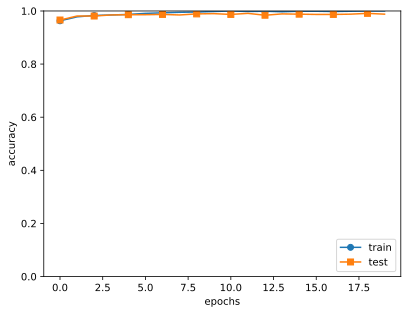

In [28]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'  # 在 Jupyter 中设置矢量图显示
import matplotlib.pyplot as plt

# 读入数据
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

# 处理花费时间较长的情况下减少数据 
# x_train, t_train = x_train[:5000], t_train[:5000]
# x_test, t_test = x_test[:1000], t_test[:1000]

max_epochs = 20

network = SimpleConvNet(input_dim=(1,28,28), 
                        conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=100, output_size=10, weight_init_std=0.01)
                        
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=100,
                  optimizer='Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000,
                  verbose=False)
trainer.train()

# 保存参数
network.save_params("params.pkl")
print("Saved Network Parameters!")

# 绘制图形
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


可视化权重变化

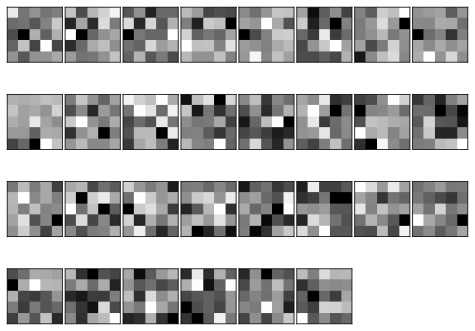

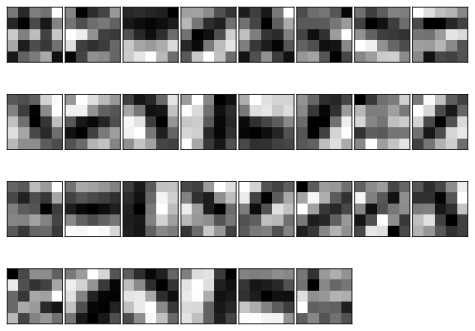

In [29]:

def filter_show(filters, nx=8, margin=3, scale=10):
    """
    c.f. https://gist.github.com/aidiary/07d530d5e08011832b12#file-draw_weight-py
    """
    FN, C, FH, FW = filters.shape
    ny = int(np.ceil(FN / nx))

    fig = plt.figure()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(FN):
        ax = fig.add_subplot(ny, nx, i+1, xticks=[], yticks=[])
        ax.imshow(filters[i, 0], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()


network = SimpleConvNet()
# 随机进行初始化后的权重
filter_show(network.params['W1'])

# 学习后的权重
network.load_params("params.pkl")
filter_show(network.params['W1'])